# **Linear Regression**


Linear Regression is a method to find a relationship between input variables (features) and an output variable (target).

***Importing Basic Libraries***

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**How can we load it in Python using pandas and see the first few rows?**.

In [2]:
df =pd.read_csv("Food_Delivery_Times (1).csv")

## Exploring the Data**

Check your dataset by some of the commands to quickly see its size, column names, missing values, and basic statistics.

In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [5]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [6]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [7]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Handling Null Values
Fill the missing values in the categorical columns by replacing them with the most frequent value in each column.

In [8]:
cat_col = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
for col in cat_col:
    df[col]=df[col].fillna(df[col].mode()[0])

In [9]:
df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [10]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [11]:
# sns.kdeplot(df['Courier_Experience_yrs'],fill = True)

## Visualizing the Data
Visualize the relationships between all pairs of variables in the dataset to see patterns and correlations.

In [12]:
# sns.pairplot(df)

### Mapping Values
Linear Regression works only on numeric data, so we need to convert categorical columns into numbers.

In [13]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()

df_copy=df.copy()

cat_col = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
for col in cat_col:
    df[col]=le.fit_transform(df[col])

In [14]:
df_copy.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [15]:
df_dumies = pd.get_dummies(df_copy,columns= ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type'])

In [16]:
df_dumies = df_dumies.astype(int)

In [17]:
df_dumies

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7,12,1,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,738,16,20,2,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,741,9,28,1,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,661,7,5,1,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,412,19,16,5,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,107,8,13,3,54,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0
996,271,16,8,9,71,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
997,861,15,26,2,81,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
998,436,14,8,0,55,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0


## **Defining Features and Target**

X (features) → known factors (distance, traffic, weather, etc.)

y (target) → what we want to predict (delivery time)


In [18]:
x_encoded = df.drop('Delivery_Time_min',axis=1)
y_encoded = df['Delivery_Time_min']

x_dumies =df_dumies.drop('Delivery_Time_min',axis=1)
y_dumies =df_dumies['Delivery_Time_min']

## Splitting Data into Train and Test Sets**

How can we check how well our model performs on unseen data?
Why do we split the dataset into two parts:

Training set (80%) → used to train the model

Testing set (20%) → used to evaluate the modelbrary.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_encoded, y_encoded, test_size=0.2, random_state=42)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model_encoded = LinearRegression()

In [22]:
model_encoded.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model_encoded.predict(X_test)
from sklearn.metrics import mean_squared_error , r2_score

mean_squared_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)
adjusted_r2 = 1 - ((1-r2)*(df.shape[0]-1))/(df.shape[0]-df.shape[1]-1)

In [24]:
r2

0.7562844966321256

In [25]:
adjusted_r2

0.7540689011469631

In [26]:
X_train, X_test, y_train, y_test = train_test_split(x_dumies, y_dumies, test_size=0.2, random_state=42)

In [27]:
model_dumies = LinearRegression()

In [28]:
model_dumies.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model_dumies.predict(X_test)
from sklearn.metrics import mean_squared_error , r2_score

mean_squared_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)
adjusted_r2 = 1 - ((1-r2)*(df_dumies.shape[0]-1))/(df_dumies.shape[0]-df_dumies.shape[1]-1)

In [30]:
r2

0.8184688733014349

In [31]:
adjusted_r2

0.8147603722452844

## **Evaluating the Model**

Check how accurate your predictions are by calculating the average error, squared error, and R² score.


In [32]:
y_train_pred = model_dumies.predict(X_train)
y_test_pred = model_dumies.predict(X_test)
r2_train = r2_score(y_train,y_train_pred)
r2_test = r2_score(y_test,y_test_pred)

In [33]:
r2_train

0.7607678543714589

In [34]:
r2_test

0.8184688733014349

### **Visualizing Predictions**


Create a scatter plot to compare actual vs predicted delivery times and visually check how well the model is performing.


<Axes: >

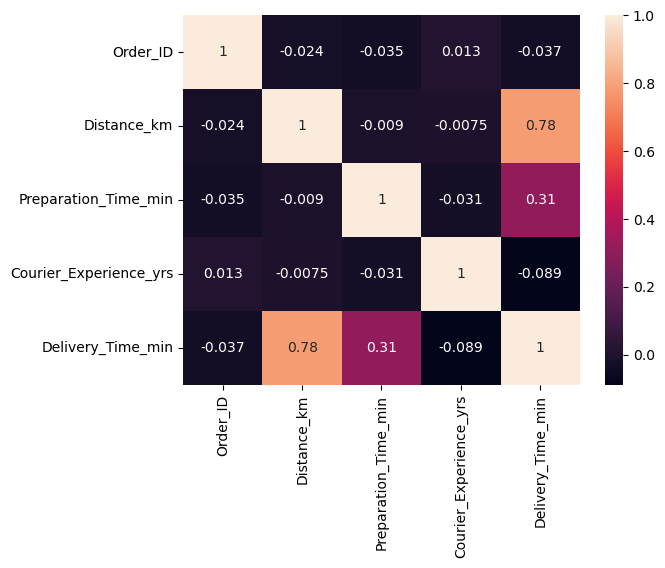

In [35]:
sns.heatmap(df_copy.corr(numeric_only = True),annot=True)

In [36]:
# Ridge Regression

In [37]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso
ridge = Ridge()
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)
r2_score(y_test, pred)

0.8183252656437566

### Lasso Regression
Train a Lasso regression model on your training data, predict delivery times for the test set, and check how accurate the predictions are using MAE, MSE, and R².

In [38]:
model = Lasso()
model.fit(X_train, y_train)
lasso_pred = model.predict(X_test)
r2_score(y_test, lasso_pred)

0.759950703018099

### Polynomial Regression
Transform your features to include polynomial terms, train a Linear Regression model on them, and calculate the mean squared error to see how well the curved model fits your data.

In [39]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

model_poly = LinearRegression()

model_poly.fit(X_train_poly, y_train)

y_pred = model_poly.predict(X_test_poly)

r2_score(y_test, y_pred)

0.7637391206727253

# Conclusion
-Predicted food delivery times using features like distance, traffic, weather, time, and courier experience.

-Applied Linear Regression for basic predictions.

-Used Ridge and Lasso to reduce overfitting and improve accuracy.

-Explored Polynomial Regression to capture nonlinear relationships.

-Evaluated models with MAE, MSE, and R² to measure performance.

-Demonstrated a real-world application of regression in optimizing delivery operations.